In [52]:
import torch
import torch.nn as nn
from torch.nn.parameter import Parameter
import torch.nn.functional as F
import torch.utils.data as data

'''
import numpy as np
from scipy.linalg import lstsq
from sklearn.linear_model import LinearRegression
'''

'\nimport numpy as np\nfrom scipy.linalg import lstsq\nfrom sklearn.linear_model import LinearRegression\n'

#FINAL

##ANFIS

###Functions

In [53]:
def gaussian2(x, p):
    '''
    Calculates Gaussian values ​​based on the input data and premise parameters of the ANFIS model.
    It is used as its membership function. It is manufactured in such a way that it also works with
    more than one input (batches).

    Parameters:
    - x (torch.Tensor): Tensor of 2D or 3D input data (for single or batch input respectively).
    - p (torch.Tensor): 3D parameter tensor containing 'mu' and 'sigma' parameters by data dimension
                        and by ANFIS rule.

    Returns:
    - torch.Tensor: 2D or 3D tensor with Resulting Gaussian values (for single or batch input
                    respectively).

    Explanation:
    This function calculates Gaussian values based on the input data `x` and the parameters `p`.
    It ensures that the standard deviation values in `p` are not zero by replacing them with a small
    value (1e-6). The formula used to compute the Gaussian values is:

    \[ \exp\left(-0.5 \cdot \left(\frac{x - p[:, :, 0]}{p[:, :, 1]}\right)^2\right) \]

    Note:
    - If `p[:, :, 1]` is zero, it is replaced with 1e-6 to prevent division by zero.

    '''
    #return torch.exp(-0.5 * torch.pow((x - p[:, :, 0])/torch.where(p[:, :, 1] == 0, torch.tensor(1.0)), 2))
    return torch.exp(-0.5 * torch.pow((x - p[:, :, 0])/torch.where(p[:, :, 1] == 0, torch.tensor(1e-6), p[:, :, 1]), 2))
    #return torch.exp(-0.5 * torch.pow((x - p[:, :, 0])/p[:, :, 1], 2))

In [54]:
def gaussian3(x, p):
    '''
    Calculates Gaussian values ​​based on the input data and premise parameters of the ANFIS model.
    It is used as its membership function. It is manufactured in such a way that it also works with
    more than one input (batches).

    Parameters:
    - x (torch.Tensor): Tensor of 2D or 3D input data (for single or batch input respectively).
    - p (torch.Tensor): 3D parameter tensor containing 'mu', 'sigma' and 'f' parameters by data
                        dimension and by ANFIS rule.

    Returns:
    - torch.Tensor: 2D or 3D tensor with Resulting Gaussian values (for single or batch input
                    respectively).

    Explanation:
    This function calculates Gaussian values based on the input data `x` and the parameters `p`.
    It ensures that the standard deviation values in `p` are not zero by replacing them with a small
    value (1e-6). The formula used to compute the Gaussian values is:

    \[ \exp\left(-p[:, :, 2] \cdot \left(\frac{x - p[:, :, 0]}{p[:, :, 1]}\right)^2\right) \]

    Note:
    - If `p[:, :, 1]` is zero, it is replaced with 1e-6 to prevent division by zero.

    '''
    return p[:, :, 2] * torch.exp(-torch.pow((x - p[:, :, 0])/torch.where(p[:, :, 1] == 0, torch.tensor(1e-6), p[:, :, 1]), 2))

In [55]:
def weighted_linear(x, c, w):
    """
    Compute the weighted linear combination of input features and coefficients (representing the
    consequent parameters of the ANFIS model). It is manufactured in such a way that it also works with
    more than one input (batches) and will be used to calculate the individual outputs of each rule of
    the ANFIS model.

    Parameters:
    - x (torch.Tensor): Input data tensor.
    - c (torch.Tensor): Coefficients tensor for the linear combination (consequent parameters).
    - w (torch.Tensor): Weights tensor for element-wise multiplication.

    Returns:
    - torch.Tensor: Resulting weighted linear combination.

    Explanation:
    This function calculates the weighted linear combination of the input features `x` and the coefficients `c`.
    It involves matrix multiplication of the input features by the transposed coefficients (excluding the last column),
    adding the last column of coefficients, and then element-wise multiplication by the weights `w`.
    The formula used is:

    \[ (x \cdot c[:, :-1].T + c[:, -1]) \cdot w \]

    Note:
    - The weights `w` are applied element-wise.

    """
    return (x @ c[:, :-1].t() + c[:, -1]).mul(w)

###Structures

####Fuzzify Layer

In [56]:
class FuzzifyLayer(nn.Module):
    '''
    Fuzzification layer of an Adaptive Neuro-Fuzzy Inference System (ANFIS) model.

    Attributes:
    - input_size (int): The size of the input features.
    - dtype (torch.dtype): The data type of the input data (used to initialize the premises with it)
    - mf (function): Membership function to use (default: gaussian2).
    - params (list): List of parameter names for the membership function (default: ['mu', 'sigma']).
    - premises (torch.nn.Parameter): Trainable parameters for the fuzzification layer.

    Methods:
    - __init__: Initializes a new FuzzifyLayer instance.
    - init_premises: Initializes the premises based on input training data.
    - forward: Performs a forward pass through the fuzzification layer.
    - premises_structure: Prints the structure of the fuzzy premises.

    Example Usage:
    >>> input_data = torch.randn((3, 4))
    >>> fuzzify_layer = FuzzifyLayer(input_data, init_rules=3)
    >>> membership_values = fuzzify_layer(input_data)

    '''
    def __init__(self, x_train, init_rules=1, mf=gaussian2, params=['mu', 'sigma'], init_mode=0):
        """
        Initializes a new FuzzifyLayer instance.

        Parameters:
        - x_train (torch.tensor): Input training data.
        - init_rules (int): The number of initial fuzzy rules (default: 1).
        - mf (function): Membership function to use (default: gaussian2).
        - params (list): List of parameter names for the membership function (default: ['mu', 'sigma']).
        - init_mode (int): Numeric flag for initializing the fuzzy premises (default: 0, meaning it will be initialized based on the input data,
                           otherwise it will be initialized randomly).

        """
        super(FuzzifyLayer, self).__init__()
        self.input_size = x_train.shape[1]
        self.dtype = x_train.dtype
        self.mf = mf
        self.params = params

        # Initialize premises
        if init_mode != 0: #random
            prems = 2 * torch.rand(self.input_size, init_rules, len(params), dtype=self.dtype) - 1
            prems[:,:,1] = (prems[:,:,1] + 1)/2
            self.premises = Parameter(prems, requires_grad=True)
        else: #based on the training input data
            self.premises = Parameter(self.init_premises(x_train, init_rules), requires_grad=True)


    def init_premises(self, x_train, init_rules):
        """
        Initializes the fuzzy premises based on input training data.

        Parameters:
        - x_train (torch.Tensor): Training data for initializing fuzzy premises.
        - init_rules (int): The number of initial fuzzy rules.

        Returns:
        - torch.Tensor: Initialized fuzzy premises.

        """
        premises = torch.zeros(self.input_size, init_rules, len(self.params), dtype=x_train.dtype)
        if init_rules > 1:
            min = torch.min(x_train, dim=0).values
            max = torch.max(x_train, dim=0).values
            stp = (max - min) / (init_rules - 1)
            for i in range(self.input_size):
                h = torch.arange(min[i], max[i] + stp[i], stp[i])
                premises[i, :, 0] = h[:init_rules]
                premises[i, :, 1] = stp[i]/2
        else:
            for i in range(self.input_size):
                premises[i, :, 0] = torch.mean(x_train[:, i])
                premises[i, :, 1] = torch.std(x_train[:, i])
        return premises


    def forward(self, x):
        """
        Performs a forward pass through the fuzzification layer.

        Parameters:
        - x (torch.Tensor): Input tensor.

        Returns:
        - torch.Tensor: Output tensor (membership values).

        """
        return self.mf(x.unsqueeze(x.dim()), self.premises)


    @property
    def premises_structure(self):
        """
        Prints the structure of the fuzzy premises.

        """
        print("Premises Structure:")
        for i in range(self.premises.data.shape[1]):
            print(f"    rule {i + 1}:")
            for j in range(self.input_size):
                print(f"        x{j} parameters:")
                [print(f"            {self.params[k]}: {self.premises[j, i, k]}") for k in range(len(self.params))]

####Firing Levels Layer

In [57]:
class FiringLevelsLayer(nn.Module):
    """
    Class for calculating firing levels in an Adaptive Neuro-Fuzzy Inference System (ANFIS) model.

    Methods:
    - __init__: Initializes a new FiringLevelsLayer instance.
    - forward: Performs a forward pass to calculate firing levels.

    Example Usage:
    >>> firing_levels_layer = FiringLevelsLayer()
    >>> firing_levels = firing_levels_layer(membership_values) #assuming 'membership_values' is the tensor obtained from the Fuzzification Layer

    """
    def __init__(self):
        """
        Initializes a new FiringLevelsLayer instance.

        """
        super(FiringLevelsLayer, self).__init__()


    def forward(self, m):
        """
        Performs a forward pass through the layer to calculate firing levels.

        Parameters:
        - m (torch.Tensor): Input tensor containing the membership values for each rule.

        Returns:
        - torch.Tensor: Output tensor (Firing levels).

        """
        w = m.prod(dim=m.dim()-2)
        return w

####Normalization Layer

In [58]:
class NormalizationLayer(nn.Module):
    """
    Class for normalize the firing levels in an Adaptive Neuro-Fuzzy Inference System (ANFIS) model.

    Methods:
    - __init__: Initializes a new NormalizeLayer instance.
    - forward: Performs a forward pass to normalize the firing levels obtained on a previous layer.

    Example Usage:
    >>> normalization_layer = NormalizationLayer()
    >>> norm_firing_levels = normalization_layer(firing_levels) #assuming 'firing_levels' is the tensor obtained from the Firing Levels Layer

    """
    def __init__(self):
        """
        Initializes a new FiringLevelsLayer instance.

        """
        super(NormalizationLayer, self).__init__()


    def forward(self, w):
        """
        Performs a forward pass through the layer to normalize the firing levels.

        Parameters:
        - x (torch.Tensor): Input tensor containing the membership values for each rule.

        Returns:
        - torch.Tensor: Output tensor (Normalized Firing levels).

        """
        sum = torch.sum(w, dim=1, keepdim=True)
        sum[sum == 0] = 1
        w = w/sum
        return w

####Consequent Layer

In [59]:
class ConsequentLayer(nn.Module):
    """
    Class for representing the fourth layer (consequent layer) of an Adaptive Neuro-Fuzzy Inference System (ANFIS) model.

    Attributes:
    - function (function): Consequent function to use (default: weighted_linear).
    - consequents (torch.nn.Parameter): Trainable parameters for the consequent layer.


    Methods:
    - __init__: Initializes a new ConsequentLayer instance.
    - forward: Performs a forward pass to calculate the consequent layer output.
    - consequents_structure: Prints the structure of the consequent parameters.

    Example Usage:
    >>> input_data = torch.randn((5, 3))  # Assuming input tensor shape (batch_size, num_input_features)
    >>> consequent_layer = ConsequentLayer(input_data.shape[1], input_data.dtype, init_rules=2)
    >>> output = consequent_layer(input_data, weights) # Assuming weight is the tensor obtained from the normalization layer with shape (batch_size, num_rules)

    """
    def __init__(self, input_size, dtype, init_rules=1, function=weighted_linear):
        """
        Initializes a new ConsequentLayer instance.

        Parameters:
        - input_size (int): Number of input features.
        - dtype (torch.dtype): Data type for the consequents.
        - init_rules (int): Number of initial rules.
        - function (callable): Consequent function to apply.

        """
        super(ConsequentLayer, self).__init__()
        self.function = function
        self.consequents = Parameter(2 * torch.rand(init_rules, input_size + 1, dtype=dtype) - 1, requires_grad=True)


    def forward(self, x, w):
        """
        Performs a forward pass to calculate the consequent layer output.

        Parameters:
        - x (torch.Tensor): Input tensor.
        - w (torch.Tensor): Weights tensor.

        Returns:
        - torch.Tensor: Output tensor (Outputs by rule of the ANFIS model).

        """
        outputs = self.function(x, self.consequents, w)
        return outputs


    @property
    def consequents_structure(self):
        """
        Prints the structure of the consequent parameters.

        """
        print("Consequents Structure:")
        for i in range(self.consequents.data.shape[0]):
            print(f"    rule {i + 1} consequent parameters: {self.consequents[i]}")

####Output Layer

In [60]:
class OutputLayer(nn.Module):
    """
    Class for representing the last layer (output layer) of an Adaptive Neuro-Fuzzy Inference System (ANFIS) model.

    Methods:
    - __init__: Initializes a new OutputLayer instance.
    - forward: Performs a forward pass to calculate the final output.

    Example Usage:
    >>> output_layer = OutputLayer()
    >>> output = output_layer(rule_outputs) # Assuming rule_outputs is the tensor obtained from the consequent layer with shape (batch_size, rules)

    """
    def __init__(self):
        """
        Initializes a new OutputLayer instance.

        """
        super(OutputLayer, self).__init__()

    def forward(self, x):
        """
        Performs a forward pass to calculate the final output by computing the sum along the last dimension of
        the input tensor.

        Parameters:
        - x (torch.Tensor): Input tensor (Rule outputs).

        Returns:
        - torch.Tensor: Final output.

        """
        return torch.sum(x, dim=-1)

###Implementation

In [61]:
class Type3ANFIS(nn.Module):
    """
    Class for representing a type 3 Adaptive Neuro-Fuzzy Inference System (ANFIS).

    Methods:
    - __init__: Initializes a new Type3ANFIS instance.
    - forward: Performs a forward pass through the ANFIS model.
    - intermediate_values: Similar to forward pass but returns the intermediate values obtained by some of the model layers.
    - rules: Returns the number of rules in the system.
    - premises_structure: Prints the structure of the premises.
    - premises: Gets the premises of the fuzzification layer as a tensor.
    - set_premises: Sets the premises parameters of the fuzzification layer.
    - consequents_structure: Prints the structure of the consequents.
    - consequents: Gets the consequents of the consequent layer as a tensor.
    - set_consequents: Sets the consequents parameters of the consequent layer.

    Example Usage:
    >>> input_data = torch.randn((5, 3))  # Assuming input tensor shape (batch_size, num_input_features)
    >>> anfis_model = Type3ANFIS(input_data, init_rules=2)
    >>> output = anfis_model(input_data)

    """


    def __init__(self, x_train, init_rules=1, cf=weighted_linear, mf=gaussian2, of=sum, mf_params=['mu', 'sigma'], init_mode=0):
        """
        Initializes a new Type3ANFIS instance.

        Parameters:
        - x_train (torch.tensor): input training data set.
        - init_rules (int): Number of initial rules (default: 1).
        - cf (callable): Consequent function to apply (default: weighted_linear).
        - mf (callable): Membership function to apply (default: gaussian2).
        - mf_params (list): List of membership function parameters (default: ['mu', 'sigma']).
        - init_mode (int): Numeric flag for initializing the fuzzy premises (default: 0, meaning it will be initialized based on the input data,
                           otherwise it will be initialized randomly).

        """
        super(Type3ANFIS, self).__init__()
        self.input_size = x_train.shape[1]
        self.dtype = x_train.dtype
        self.mf_params = mf_params

        self.fuzzify_layer = FuzzifyLayer(x_train, init_rules, mf, mf_params, init_mode)
        self.firing_levels_layer = FiringLevelsLayer()
        self.normalization_layer = NormalizationLayer()
        self.consequent_layer = ConsequentLayer(self.input_size, self.dtype, init_rules, cf)
        self.output_layer = OutputLayer()


    def forward(self, x):
        """
        Performs a forward pass through the ANFIS model.

        Parameters:
        - x (torch.Tensor): Input tensor.

        Returns:
        - torch.Tensor: Final output.

        """
        output = self.fuzzify_layer(x)
        output = self.consequent_layer(x, self.normalization_layer(self.firing_levels_layer(output)))
        output = self.output_layer(output)
        return output


    def intermediate_values(self, x):
        """
        Computes normalized firing levels based on input data.

        Parameters:
        - x (torch.Tensor): Input tensor.

        Returns:
        - w (torch.Tensor): Firing levels.
        - w_norm (torch.Tensor): Normalized firing levels.
        - outputs (torch.Tensor): Outputs by rule of the model

        """
        w = self.fuzzify_layer(x)
        w = self.firing_levels_layer(w)
        w_norm = self.normalization_layer(w)
        outputs = self.consequent_layer(x, w_norm)
        return w, w_norm, outputs


    @property
    def rules(self):
        """
        Returns the number of rules in the system.

        """
        return self.consequents.shape[0]


    @property
    def premises_structure(self):
        """
        Prints the structure of the premises.

        """
        self.fuzzify_layer.premises_structure


    @property
    def premises(self):
        """
        Return the premises parameters of the fuzzify layer as a torch tensor.

        """
        return self.fuzzify_layer.premises.data


    def set_premises(self, premises):
        """
        Sets the premises of the fuzzification layer.

        Parameters:
        - premises (torch.Tensor): New premises.

        """
        self.fuzzify_layer.premises = Parameter(premises, requires_grad=True)


    @property
    def consequents_structure(self):
        """
        Prints the structure of the consequents.

        """
        self.consequent_layer.consequents_structure


    @property
    def consequents(self):
        """
        Returns the consequents of the consequent layer as a torch.tensor.

        """
        return self.consequent_layer.consequents.data


    def set_consequents(self, consequents):
        """
        Sets the consequents of the consequent layer.

        Parameters:
        - consequents (torch.Tensor): New consequents.

        """
        self.consequent_layer.consequents = Parameter(consequents, requires_grad=True)

###Testing

In [62]:
x = torch.tensor([[0.8272, 0.6737],
                  [0.6561, 0.6231],
                  [0.5756, 0.3885]])

y = torch.tensor([0.5, 2.0, 2.5])

model = Type3ANFIS(x, init_rules=3)

prem = torch.tensor([[[0.0462, 0.3922],
                      [0.0971, 0.6555],
                      [0.8235, 0.1712]],

                     [[0.7655, 0.6948],
                      [0.7952, 0.3171],
                      [0.1869, 0.9502]]])
model.set_premises(prem)

cons = torch.tensor([[-0.3726, -0.1463, 0.6341],
                     [-0.1292, 0.1112, 0.6404],
                     [0.6947, -0.6779, -0.4394]])
model.set_consequents(cons)

print("premises :", model.premises)
print("\nconsequents :", model.consequents)

premises : tensor([[[0.0462, 0.3922],
         [0.0971, 0.6555],
         [0.8235, 0.1712]],

        [[0.7655, 0.6948],
         [0.7952, 0.3171],
         [0.1869, 0.9502]]])

consequents : tensor([[-0.3726, -0.1463,  0.6341],
        [-0.1292,  0.1112,  0.6404],
        [ 0.6947, -0.6779, -0.4394]])


In [63]:
print("model.fuzzify_layer.premises", model.fuzzify_layer.premises)
print("model.fuzzify_layer.premises.grad", model.fuzzify_layer.premises.grad)

pred = model(x)

loss = nn.functional.mse_loss(pred, y)
loss.backward()

print("model.fuzzify_layer.premises", model.fuzzify_layer.premises)
print("model.fuzzify_layer.premises.grad", model.fuzzify_layer.premises.grad)

model.fuzzify_layer.premises Parameter containing:
tensor([[[0.0462, 0.3922],
         [0.0971, 0.6555],
         [0.8235, 0.1712]],

        [[0.7655, 0.6948],
         [0.7952, 0.3171],
         [0.1869, 0.9502]]], requires_grad=True)
model.fuzzify_layer.premises.grad None
model.fuzzify_layer.premises Parameter containing:
tensor([[[0.0462, 0.3922],
         [0.0971, 0.6555],
         [0.8235, 0.1712]],

        [[0.7655, 0.6948],
         [0.7952, 0.3171],
         [0.1869, 0.9502]]], requires_grad=True)
model.fuzzify_layer.premises.grad tensor([[[-0.4105, -0.5989],
         [-0.6198, -0.5281],
         [-3.7714,  4.7533]],

        [[ 0.0677, -0.0330],
         [ 1.2536, -1.2473],
         [ 0.2234,  0.0897]]])


In [64]:
x.dtype

torch.float32

In [65]:
model.premises.dtype

torch.float32

In [66]:
model.intermediate_values(x)

(tensor([[0.1365, 0.4997, 0.8768],
         [0.2923, 0.6000, 0.5580],
         [0.3471, 0.3366, 0.3427]], grad_fn=<ProdBackward1>),
 tensor([[0.0902, 0.3303, 0.5795],
         [0.2015, 0.4137, 0.3848],
         [0.3382, 0.3279, 0.3339]], grad_fn=<DivBackward0>),
 tensor([[ 0.0205,  0.2010, -0.1863],
         [ 0.0602,  0.2585, -0.1562],
         [ 0.1227,  0.1998, -0.1011]], grad_fn=<MulBackward0>))

In [67]:
model0 = Type3ANFIS(x, init_rules=2)

In [68]:
x

tensor([[0.8272, 0.6737],
        [0.6561, 0.6231],
        [0.5756, 0.3885]])

In [69]:
torch.rand(3,2)

tensor([[0.7342, 0.0132],
        [0.8862, 0.7235],
        [0.9870, 0.4168]])

In [70]:
model0.intermediate_values(x)

(tensor([[0.0183, 1.0000],
         [0.2106, 0.3724],
         [1.0000, 0.0183]], grad_fn=<ProdBackward1>),
 tensor([[0.0180, 0.9820],
         [0.3612, 0.6388],
         [0.9820, 0.0180]], grad_fn=<DivBackward0>),
 tensor([[-0.0230,  0.5460],
         [-0.4387,  0.3723],
         [-1.0334,  0.0096]], grad_fn=<MulBackward0>))

###Testing

In [71]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from mpl_toolkits.mplot3d import Axes3D


def z(x, y):
  return ((3) * ((1-x)**2) * (np.exp(-(x**2)-((y+1)**2))) - (10) * ((x/5)-(x**3)-(y**5)) * (np.exp(-(x**2)-(y**2))) - (1/3)*np.exp(-(x+1)**2-(y**2)))


x0 = np.random.uniform(-3,4,10000)
x1 = np.random.uniform(-3,4,10000)

e = np.random.normal(0,0.4,10000)
Y = z(x0,x1) + e


scaler = MinMaxScaler(feature_range=(0, 1))
vstack_train = np.vstack((x0,x1)).T
scaled_train = scaler.fit_transform(vstack_train)


loader = data.DataLoader(data.TensorDataset(torch.from_numpy(scaled_train), torch.from_numpy(Y)), batch_size = 8, shuffle = True)
x_trainset = loader.dataset.tensors[0]
y_trainset = loader.dataset.tensors[1]

In [72]:
model = Type3ANFIS(x_trainset)

In [73]:
w, w_norm, outputs_by_rule = model.intermediate_values(x_trainset)

In [74]:
print("model.fuzzify_layer.premises", model.fuzzify_layer.premises)
print("model.fuzzify_layer.premises.grad", model.fuzzify_layer.premises.grad)

pred = model(x_trainset)

loss = nn.functional.mse_loss(pred, y_trainset)
loss.backward()

print("model.fuzzify_layer.premises", model.fuzzify_layer.premises)
print("model.fuzzify_layer.premises.grad", model.fuzzify_layer.premises.grad)

model.fuzzify_layer.premises Parameter containing:
tensor([[[0.4997, 0.2874]],

        [[0.5007, 0.2890]]], dtype=torch.float64, requires_grad=True)
model.fuzzify_layer.premises.grad None
model.fuzzify_layer.premises Parameter containing:
tensor([[[0.4997, 0.2874]],

        [[0.5007, 0.2890]]], dtype=torch.float64, requires_grad=True)
model.fuzzify_layer.premises.grad tensor([[[-1.8984e-18, -3.4105e-18]],

        [[ 2.2296e-18, -2.3378e-18]]], dtype=torch.float64)


##SONFIS

###OLS

####Premises update

In [75]:
'''
def premisesUpdate(ANFISmodel, x_train, y_train, y=0.01, loss_function=nn.functional.mse_loss, freezed=None):
    pred = ANFISmodel(x_train)

    loss = loss_function(pred, y_train)
    loss.backward()

    alpha = y / torch.sqrt(torch.sum(torch.pow(ANFISmodel.fuzzify_layer.premises.grad, 2)))


    if freezed == None:
        freezed = torch.zeros(ANFISmodel.consequents.shape[0])

    new_premises = ANFISmodel.premises

    vs = new_premises[:,:,0].t()
    sigmas = new_premises[:,:,1].t()

    new_vs = torch.zeros_like(vs)
    new_sigmas = torch.zeros_like(sigmas)

    _, w_norm, outputs_by_rule = ANFISmodel.intermediate_values(x_train)

    for k in range(ANFISmodel.rules):
        if freezed[k] == 0:
            A = 4*alpha*(1/torch.pow(sigmas[k], 2))*(x_train - vs[k])
            B = 4*alpha*(1/torch.pow(sigmas[k], 3))*torch.pow((x_train - vs[k]), 2)
            wk = w_norm[:,k].unsqueeze(0).t()
            fk = outputs_by_rule[:,k]
            zk = ((fk-pred)*(y_train-pred)).unsqueeze(0).t()

            new_vs[k] = torch.sum(A*wk*zk, dim=0)
            new_sigmas[k] = torch.sum(B*wk*zk, dim=0)

    new_premises[:, :, 0] += new_vs.t()
    new_premises[:, :, 1] += new_sigmas.t()

    return new_premises;
    '''

'\ndef premisesUpdate(ANFISmodel, x_train, y_train, y=0.01, loss_function=nn.functional.mse_loss, freezed=None):\n    pred = ANFISmodel(x_train)\n\n    loss = loss_function(pred, y_train)\n    loss.backward()\n\n    alpha = y / torch.sqrt(torch.sum(torch.pow(ANFISmodel.fuzzify_layer.premises.grad, 2)))\n\n\n    if freezed == None:\n        freezed = torch.zeros(ANFISmodel.consequents.shape[0])\n\n    new_premises = ANFISmodel.premises\n\n    vs = new_premises[:,:,0].t()\n    sigmas = new_premises[:,:,1].t()\n\n    new_vs = torch.zeros_like(vs)\n    new_sigmas = torch.zeros_like(sigmas)\n\n    _, w_norm, outputs_by_rule = ANFISmodel.intermediate_values(x_train)\n\n    for k in range(ANFISmodel.rules):\n        if freezed[k] == 0:\n            A = 4*alpha*(1/torch.pow(sigmas[k], 2))*(x_train - vs[k])\n            B = 4*alpha*(1/torch.pow(sigmas[k], 3))*torch.pow((x_train - vs[k]), 2)\n            wk = w_norm[:,k].unsqueeze(0).t()\n            fk = outputs_by_rule[:,k]\n            zk = (

In [76]:
'''
model.fuzzify_layer.premises.grad = None
print(model.fuzzify_layer.premises.grad)
'''

'\nmodel.fuzzify_layer.premises.grad = None\nprint(model.fuzzify_layer.premises.grad)\n'

#####Testing

In [77]:
'''
x = torch.tensor([[0.8272, 0.6737],
                  [0.6561, 0.6231],
                  [0.5756, 0.3885]])

y = torch.tensor([0.5, 2, 2.5])

model = Type3ANFIS(x.shape[1], x.dtype, init_rules=3)

prem = torch.tensor([[[0.0462, 0.3922],
                      [0.0971, 0.6555],
                      [0.8235, 0.1712]],

                     [[0.7655, 0.6948],
                      [0.7952, 0.3171],
                      [0.1869, 0.9502]]])
model.set_premises(Parameter(prem, requires_grad=True))

cons = torch.tensor([[-0.3726, -0.1463, 0.6341],
                     [-0.1292, 0.1112, 0.6404],
                     [0.6947, -0.6779, -0.4394]])
model.set_consequents(Parameter(cons, requires_grad=True))

print("premises :", model.premises)
print("\nconsequents :", model.consequents)
pred = model(x)
print("\nmodel(x) :", pred)
'''

'\nx = torch.tensor([[0.8272, 0.6737],\n                  [0.6561, 0.6231],\n                  [0.5756, 0.3885]])\n\ny = torch.tensor([0.5, 2, 2.5])\n\nmodel = Type3ANFIS(x.shape[1], x.dtype, init_rules=3)\n\nprem = torch.tensor([[[0.0462, 0.3922],\n                      [0.0971, 0.6555],\n                      [0.8235, 0.1712]],\n\n                     [[0.7655, 0.6948],\n                      [0.7952, 0.3171],\n                      [0.1869, 0.9502]]])\nmodel.set_premises(Parameter(prem, requires_grad=True))\n\ncons = torch.tensor([[-0.3726, -0.1463, 0.6341],\n                     [-0.1292, 0.1112, 0.6404],\n                     [0.6947, -0.6779, -0.4394]])\nmodel.set_consequents(Parameter(cons, requires_grad=True))\n\nprint("premises :", model.premises)\nprint("\nconsequents :", model.consequents)\npred = model(x)\nprint("\nmodel(x) :", pred)\n'

In [78]:
#new_premises = premisesUpdate(model, x, y)

In [79]:
#new_premises

In [80]:
#loss

####Consequents update

In [81]:
'''
def consequentsUpdate(ANFISmodel, x_train, y_train, freezed=None):
    """
    Update the consequents of an ANFIS model based on input-output pairs.

    Parameters:
    - consequents (torch.Tensor): Current consequent parameters of the model.
    - x_train (torch.Tensor): Input training data.
    - y_train (torch.Tensor): Output training data.
    - w_norm (torch.Tensor): Normalized firing levels.
    - freezed (torch.Tensor or None): Binary tensor indicating which rules of the model are freezed (default: None).

    Returns:
    - new_consequents (torch.Tensor): Updated consequent parameters.

    """
    new_consequents = torch.zeros_like(ANFISmodel.consequents)
    #new_consequents = torch.zeros_like(ANFISmodel.consequents).numpy()

    _, w_norm, _ = ANFISmodel.intermediate_values(x_train)

    xe = torch.cat([x_train, torch.ones(x_train.shape[0], 1)], dim=1) #extended x_train
    #xe = torch.cat([torch.ones(x_train.shape[0], 1), x_train], dim=1) #extended x_train

    if freezed == None:
        freezed = torch.zeros(new_consequents.shape[0])

    for i in range(new_consequents.shape[0]):
        if freezed[i] == 0:
            #firing_levels diagonal matrix
            w_diag = torch.diag(w_norm[:, i])

            #new consequents
            #pytorch

            #new_consequents[i], _, _, _ = torch.linalg.lstsq(xe.t() @ w_diag @ xe, xe.t() @ w_diag @ y_train)
            new_consequents[i], _, _, _ = torch.linalg.lstsq(w_diag @ xe, w_diag @ y_train)

            #numpy
            #new_consequents[i], _, _, _ = np.linalg.lstsq(xe.t().numpy() @ w_diag.detach().numpy() @ xe.numpy(), xe.t().numpy() @ w_diag.detach().numpy() @ y_train.numpy(), rcond=None)
            #new_consequents[i], _, _, _ = np.linalg.lstsq(w_diag @ xe, w_diag @ y_train, rcond=None)

            #scipy
            #new_consequents[i], _, _, _ = lstsq(xe.t().numpy() @ w_diag.detach().numpy() @ xe.numpy(), xe.t().numpy() @ w_diag.detach().numpy() @ y_train.numpy())
            #new_consequents[i], _, _, _ = lstsq(w_diag @ xe, w_diag @ y_train)

            #sklearn
            #regress = LinearRegression()
            #regress.fit(xe.t().numpy() @ w_diag.detach().numpy() @ xe.numpy(), xe.t().numpy() @ w_diag.detach().numpy() @ y_train.numpy())
            #new_consequents[i] = regress.coef_
    return new_consequents;
    '''

'\ndef consequentsUpdate(ANFISmodel, x_train, y_train, freezed=None):\n    """\n    Update the consequents of an ANFIS model based on input-output pairs.\n\n    Parameters:\n    - consequents (torch.Tensor): Current consequent parameters of the model.\n    - x_train (torch.Tensor): Input training data.\n    - y_train (torch.Tensor): Output training data.\n    - w_norm (torch.Tensor): Normalized firing levels.\n    - freezed (torch.Tensor or None): Binary tensor indicating which rules of the model are freezed (default: None).\n\n    Returns:\n    - new_consequents (torch.Tensor): Updated consequent parameters.\n\n    """\n    new_consequents = torch.zeros_like(ANFISmodel.consequents)\n    #new_consequents = torch.zeros_like(ANFISmodel.consequents).numpy()\n\n    _, w_norm, _ = ANFISmodel.intermediate_values(x_train)\n\n    xe = torch.cat([x_train, torch.ones(x_train.shape[0], 1)], dim=1) #extended x_train\n    #xe = torch.cat([torch.ones(x_train.shape[0], 1), x_train], dim=1) #extended 

In [82]:
'''

def consequentsUpdate(ANFISmodel, x_train, y_train, freezed=None):
    current_consequents = ANFISmodel.consequents
    new_consequents = torch.zeros_like(ANFISmodel.consequents)

    _, w_norm, _ = ANFISmodel.intermediate_values(x_train)
    xe = torch.cat([x_train, torch.ones(x_train.shape[0], 1)], dim=1) #extended x_train
    #X = torch.tensor([])

    if freezed == None:
        freezed = torch.zeros(new_consequents.shape[0])

    fs = torch.tensor([])
    for i in range(new_consequents.shape[0]):
        if freezed[i] == 0:
            w_diag = torch.diag(w_norm[:, i])
            fs = torch.cat((fs, w_diag), dim=1)
            print(xe)
            print(w_diag)
            print(fs)
            print("\n")

    X = xe.repeat(1, new_consequents.shape[0])
    new_consequents, _, _, _ = torch.linalg.lstsq(fs * X, y_train)
    return new_consequents;
    '''


'\n\ndef consequentsUpdate(ANFISmodel, x_train, y_train, freezed=None):\n    current_consequents = ANFISmodel.consequents\n    new_consequents = torch.zeros_like(ANFISmodel.consequents)\n\n    _, w_norm, _ = ANFISmodel.intermediate_values(x_train)\n    xe = torch.cat([x_train, torch.ones(x_train.shape[0], 1)], dim=1) #extended x_train\n    #X = torch.tensor([])\n\n    if freezed == None:\n        freezed = torch.zeros(new_consequents.shape[0])\n\n    fs = torch.tensor([])\n    for i in range(new_consequents.shape[0]):\n        if freezed[i] == 0:\n            w_diag = torch.diag(w_norm[:, i])\n            fs = torch.cat((fs, w_diag), dim=1)\n            print(xe)\n            print(w_diag)\n            print(fs)\n            print("\n")\n\n    X = xe.repeat(1, new_consequents.shape[0])\n    new_consequents, _, _, _ = torch.linalg.lstsq(fs * X, y_train)\n    return new_consequents;\n    '

In [83]:
'''
def consequentsUpdate(ANFISmodel, x_train, y_train, freezed=None):
    current_consequents = ANFISmodel.consequents
    new_consequents = torch.zeros_like(ANFISmodel.consequents)

    _, w_norm, _ = ANFISmodel.intermediate_values(x_train)
    xe = torch.cat([x_train, torch.ones(x_train.shape[0], 1)], dim=1) #extended x_train

    if freezed == None:
        freezed = torch.zeros(ANFISmodel.rules)

    fs = w_norm.unsqueeze(2).repeat(1, 1, xe.shape[1]).view(w_norm.shape[0], -1)
    X = xe.repeat(1, ANFISmodel.rules)

    new_consequents, _, _, _ = torch.linalg.lstsq(fs * X, y_train)
    new_consequents = torch.reshape(new_consequents, (ANFISmodel.rules, xe.shape[1]))

    current_consequents[freezed == 0] = new_consequents[freezed == 0]

    return current_consequents;
'''

'\ndef consequentsUpdate(ANFISmodel, x_train, y_train, freezed=None):\n    current_consequents = ANFISmodel.consequents\n    new_consequents = torch.zeros_like(ANFISmodel.consequents)\n\n    _, w_norm, _ = ANFISmodel.intermediate_values(x_train)\n    xe = torch.cat([x_train, torch.ones(x_train.shape[0], 1)], dim=1) #extended x_train\n\n    if freezed == None:\n        freezed = torch.zeros(ANFISmodel.rules)\n\n    fs = w_norm.unsqueeze(2).repeat(1, 1, xe.shape[1]).view(w_norm.shape[0], -1)\n    X = xe.repeat(1, ANFISmodel.rules)\n\n    new_consequents, _, _, _ = torch.linalg.lstsq(fs * X, y_train)\n    new_consequents = torch.reshape(new_consequents, (ANFISmodel.rules, xe.shape[1]))\n\n    current_consequents[freezed == 0] = new_consequents[freezed == 0]\n\n    return current_consequents;\n'

#####Testing

In [84]:
'''
x = torch.tensor([[0.8272, 0.6737],
                  [0.6561, 0.6231],
                  [0.5756, 0.3885]])

y = torch.tensor([0.5, 2, 2.5])

model = Type3ANFIS(x.shape[1], x.dtype, init_rules=3)

prem = torch.tensor([[[0.0462, 0.3922],
                      [0.0971, 0.6555],
                      [0.8235, 0.1712]],

                     [[0.7655, 0.6948],
                      [0.7952, 0.3171],
                      [0.1869, 0.9502]]])
model.set_premises(Parameter(prem, requires_grad=True))

cons = torch.tensor([[-0.3726, -0.1463, 0.6341],
                     [-0.1292, 0.1112, 0.6404],
                     [0.6947, -0.6779, -0.4394]])
model.set_consequents(Parameter(cons, requires_grad=True))

print("premises :", model.premises)
print("\nconsequents :", model.consequents)
pred = model(x)
print("\nmodel(x) :", pred)
'''

'\nx = torch.tensor([[0.8272, 0.6737],\n                  [0.6561, 0.6231],\n                  [0.5756, 0.3885]])\n\ny = torch.tensor([0.5, 2, 2.5])\n\nmodel = Type3ANFIS(x.shape[1], x.dtype, init_rules=3)\n\nprem = torch.tensor([[[0.0462, 0.3922],\n                      [0.0971, 0.6555],\n                      [0.8235, 0.1712]],\n\n                     [[0.7655, 0.6948],\n                      [0.7952, 0.3171],\n                      [0.1869, 0.9502]]])\nmodel.set_premises(Parameter(prem, requires_grad=True))\n\ncons = torch.tensor([[-0.3726, -0.1463, 0.6341],\n                     [-0.1292, 0.1112, 0.6404],\n                     [0.6947, -0.6779, -0.4394]])\nmodel.set_consequents(Parameter(cons, requires_grad=True))\n\nprint("premises :", model.premises)\nprint("\nconsequents :", model.consequents)\npred = model(x)\nprint("\nmodel(x) :", pred)\n'

In [85]:
'''
x = torch.tensor([[0.8272, 0.6737],
                  [0.6561, 0.6231],
                  [0.5756, 0.3885]])

y = torch.tensor([0.5, 2, 2.5])

model = Type3ANFIS(x.shape[1], x.dtype, init_rules=2)

prem = torch.tensor([[[0.0462, 0.3922],
                      [0.0971, 0.6555]],

                     [[0.7655, 0.6948],
                      [0.7952, 0.3171]]])
model.set_premises(Parameter(prem, requires_grad=True))

cons = torch.tensor([[-0.3726, -0.1463, 0.6341],
                     [-0.1292, 0.1112, 0.6404]])
model.set_consequents(Parameter(cons, requires_grad=True))

print("premises :", model.premises)
print("\nconsequents :", model.consequents)
pred = model(x)
print("\nmodel(x) :", pred)
'''

'\nx = torch.tensor([[0.8272, 0.6737],\n                  [0.6561, 0.6231],\n                  [0.5756, 0.3885]])\n\ny = torch.tensor([0.5, 2, 2.5])\n\nmodel = Type3ANFIS(x.shape[1], x.dtype, init_rules=2)\n\nprem = torch.tensor([[[0.0462, 0.3922],\n                      [0.0971, 0.6555]],\n\n                     [[0.7655, 0.6948],\n                      [0.7952, 0.3171]]])\nmodel.set_premises(Parameter(prem, requires_grad=True))\n\ncons = torch.tensor([[-0.3726, -0.1463, 0.6341],\n                     [-0.1292, 0.1112, 0.6404]])\nmodel.set_consequents(Parameter(cons, requires_grad=True))\n\nprint("premises :", model.premises)\nprint("\nconsequents :", model.consequents)\npred = model(x)\nprint("\nmodel(x) :", pred)\n'

In [86]:
'''
new_consequents = consequentsUpdate(model, x, y)
new_consequents
'''

'\nnew_consequents = consequentsUpdate(model, x, y)\nnew_consequents\n'

In [87]:
#model.set_consequents(new_consequents)

In [88]:
#model.consequents

In [89]:
#model(x)

In [90]:
#x.shape[0]

####Implementation

In [91]:
'''
def OLS(ANFISmodel, loader, epochs=1, y=0.01, loss_function=nn.functional.mse_loss, freezed=None, validation=0, return_loss=True):
    history = torch.tensor([])
    val_history = torch.tensor([])
    ep = 0
    while (ep < epochs):
        x_train = loader.dataset.tensors[0]
        y_train = loader.dataset.tensors[1]

        if (validation != 0):
            split_index = int(x_train.shape[0] * validation)
            x_train, x_val = torch.split(x_train, [split_index, x_train.shape[0] - split_index])
            y_train, y_val = torch.split(y_train, [split_index, y_train.shape[0] - split_index])

        ANFISmodel.set_consequents(consequentsUpdate(ANFISmodel, x_train, y_train, freezed))
        ANFISmodel.set_premises(premisesUpdate(ANFISmodel, x_train, y_train, y, loss_function, freezed))

        if return_loss:
            with torch.no_grad():
                if (validation != 0):
                    val_loss = loss_function(ANFISmodel(x_val), y_val)
                    val_history = torch.cat([val_history, torch.tensor([val_loss])])
                loss = loss_function(ANFISmodel(x_train), y_train)
                history = torch.cat([history, torch.tensor([loss])])

    if return_loss:
        if (validation != 0):
            return history, val_history
        return history

'''

'\ndef OLS(ANFISmodel, loader, epochs=1, y=0.01, loss_function=nn.functional.mse_loss, freezed=None, validation=0, return_loss=True):\n    history = torch.tensor([])\n    val_history = torch.tensor([])\n    ep = 0\n    while (ep < epochs):\n        x_train = loader.dataset.tensors[0]\n        y_train = loader.dataset.tensors[1]\n\n        if (validation != 0):\n            split_index = int(x_train.shape[0] * validation)\n            x_train, x_val = torch.split(x_train, [split_index, x_train.shape[0] - split_index])\n            y_train, y_val = torch.split(y_train, [split_index, y_train.shape[0] - split_index])\n\n        ANFISmodel.set_consequents(consequentsUpdate(ANFISmodel, x_train, y_train, freezed))\n        ANFISmodel.set_premises(premisesUpdate(ANFISmodel, x_train, y_train, y, loss_function, freezed))\n\n        if return_loss:\n            with torch.no_grad():\n                if (validation != 0):\n                    val_loss = loss_function(ANFISmodel(x_val), y_val)\n   

#####Testing

In [92]:
'''
x = torch.tensor([[0.8272, 0.6737],
                  [0.6561, 0.6231],
                  [0.5756, 0.3885]])

y = torch.tensor([0.5, 2, 2.5])

model = Type3ANFIS(x.shape[1], x.dtype, init_rules=3)

prem = torch.tensor([[[0.0462, 0.3922],
                      [0.0971, 0.6555],
                      [0.8235, 0.1712]],

                     [[0.7655, 0.6948],
                      [0.7952, 0.3171],
                      [0.1869, 0.9502]]])
model.set_premises(Parameter(prem, requires_grad=True))

cons = torch.tensor([[-0.3726, -0.1463, 0.6341],
                     [-0.1292, 0.1112, 0.6404],
                     [0.6947, -0.6779, -0.4394]])
model.set_consequents(Parameter(cons, requires_grad=True))

print("premises :", model.premises)
print("\nconsequents :", model.consequents)
pred = model(x)
print("\nmodel(x) :", pred)

loader = data.DataLoader(data.TensorDataset(x, y), batch_size = 2)
'''

'\nx = torch.tensor([[0.8272, 0.6737],\n                  [0.6561, 0.6231],\n                  [0.5756, 0.3885]])\n\ny = torch.tensor([0.5, 2, 2.5])\n\nmodel = Type3ANFIS(x.shape[1], x.dtype, init_rules=3)\n\nprem = torch.tensor([[[0.0462, 0.3922],\n                      [0.0971, 0.6555],\n                      [0.8235, 0.1712]],\n\n                     [[0.7655, 0.6948],\n                      [0.7952, 0.3171],\n                      [0.1869, 0.9502]]])\nmodel.set_premises(Parameter(prem, requires_grad=True))\n\ncons = torch.tensor([[-0.3726, -0.1463, 0.6341],\n                     [-0.1292, 0.1112, 0.6404],\n                     [0.6947, -0.6779, -0.4394]])\nmodel.set_consequents(Parameter(cons, requires_grad=True))\n\nprint("premises :", model.premises)\nprint("\nconsequents :", model.consequents)\npred = model(x)\nprint("\nmodel(x) :", pred)\n\nloader = data.DataLoader(data.TensorDataset(x, y), batch_size = 2)\n'

In [93]:
#OLS(model, loader)

####POO Implementation

In [94]:
class OLS():
    def __init__(self, epochs, y=0.01, loss_function=nn.functional.mse_loss, validation=0):
        self.epochs = epochs
        self.y = y
        self.loss_function = loss_function
        self.validation = validation
        self.train_history = torch.tensor([])
        self.val_history = torch.tensor([])

    '''
    def __call__(self, ANFISmodel, loader, freezed=None):
        ep = 0
        while (ep < self.epochs):
            x_train = loader.dataset.tensors[0]
            y_train = loader.dataset.tensors[1]

            if (self.validation != 0):
                split_index = int(x_train.shape[0] * self.validation)
                x_train, x_val = torch.split(x_train, [split_index, x_train.shape[0] - split_index])
                y_train, y_val = torch.split(y_train, [split_index, y_train.shape[0] - split_index])

            ANFISmodel.set_consequents(self.consequentsUpdate(ANFISmodel, x_train, y_train, freezed))
            ANFISmodel.set_premises(self.premisesUpdate(ANFISmodel, x_train, y_train, self.y, self.loss_function, freezed))

            with torch.no_grad():
                if (self.validation != 0):
                    val_loss = self.loss_function(ANFISmodel(x_val), y_val)
                    self.val_history = torch.cat([self.val_history, torch.tensor([val_loss])])

                loss = self.loss_function(ANFISmodel(x_train), y_train)
                self.train_history = torch.cat([self.train_history, torch.tensor([loss])])

            ep += 1
    '''


    def __call__(self, ANFISmodel, loader, freezed=None):
        x_train = loader.dataset.tensors[0]
        y_train = loader.dataset.tensors[1]

        if (self.validation != 0):
            split_index = int(x_train.shape[0] * self.validation)
            x_train, x_val = torch.split(x_train, [split_index, x_train.shape[0] - split_index])
            y_train, y_val = torch.split(y_train, [split_index, y_train.shape[0] - split_index])

        ANFISmodel.set_consequents(self.consequentsUpdate(ANFISmodel, x_train, y_train, freezed))
        ep = 0
        while (ep < self.epochs):
            ANFISmodel.set_premises(self.premisesUpdate(ANFISmodel, x_train, y_train, self.y, self.loss_function, freezed))
            ep += 1
        ANFISmodel.set_consequents(self.consequentsUpdate(ANFISmodel, x_train, y_train, freezed))

        with torch.no_grad():
            if (self.validation != 0):
                val_loss = self.loss_function(ANFISmodel(x_val), y_val)
                self.val_history = torch.cat([self.val_history, torch.tensor([val_loss])])

            loss = self.loss_function(ANFISmodel(x_train), y_train)
            self.train_history = torch.cat([self.train_history, torch.tensor([loss])])

    '''
    def __call__(self, ANFISmodel, loader, freezed=None):
        ep = 0
        while (ep < self.epochs):
            x_train = loader.dataset.tensors[0]
            y_train = loader.dataset.tensors[1]

            if (self.validation != 0):
                split_index = int(x_train.shape[0] * self.validation)
                x_train, x_val = torch.split(x_train, [split_index, x_train.shape[0] - split_index])
                y_train, y_val = torch.split(y_train, [split_index, y_train.shape[0] - split_index])

            ep0 = 0
            while (ep0 < self.epochs):
                ANFISmodel.set_premises(self.premisesUpdate(ANFISmodel, x_train, y_train, self.y, self.loss_function, freezed))
                ep0 += 1
            ANFISmodel.set_consequents(self.consequentsUpdate(ANFISmodel, x_train, y_train, freezed))

            with torch.no_grad():
                if (self.validation != 0):
                    val_loss = self.loss_function(ANFISmodel(x_val), y_val)
                    self.val_history = torch.cat([self.val_history, torch.tensor([val_loss])])

                loss = self.loss_function(ANFISmodel(x_train), y_train)
                self.train_history = torch.cat([self.train_history, torch.tensor([loss])])

            ep += 1
    '''

    def consequentsUpdate(self, ANFISmodel, x_train, y_train, freezed=None):
        current_consequents = ANFISmodel.consequents
        new_consequents = torch.zeros_like(ANFISmodel.consequents)

        _, w_norm, _ = ANFISmodel.intermediate_values(x_train)
        xe = torch.cat([x_train, torch.ones(x_train.shape[0], 1)], dim=1)

        if freezed == None:
            freezed = torch.zeros(ANFISmodel.rules)

        fs = w_norm.unsqueeze(2).repeat(1, 1, xe.shape[1]).view(w_norm.shape[0], -1)
        X = xe.repeat(1, ANFISmodel.rules)

        new_consequents, _, _, _ = torch.linalg.lstsq(fs * X, y_train)
        new_consequents = torch.reshape(new_consequents, (ANFISmodel.rules, xe.shape[1]))

        current_consequents[freezed == 0] = new_consequents[freezed == 0]

        return new_consequents;


    def premisesUpdate(self, ANFISmodel, x_train, y_train, y=0.01, loss_function=nn.functional.mse_loss, freezed=None):
        pred = ANFISmodel(x_train)

        loss = loss_function(pred, y_train)
        loss.backward()

        alpha = y / torch.sqrt(torch.sum(torch.pow(ANFISmodel.fuzzify_layer.premises.grad, 2)))

        if freezed == None:
            freezed = torch.zeros(ANFISmodel.consequents.shape[0])

        new_premises = ANFISmodel.premises

        vs = new_premises[:,:,0].t()
        sigmas = new_premises[:,:,1].t()

        new_vs = torch.zeros_like(vs)
        new_sigmas = torch.zeros_like(sigmas)

        _, w_norm, outputs_by_rule = ANFISmodel.intermediate_values(x_train)

        for k in range(ANFISmodel.rules):
            if freezed[k] == 0:
                A = 4*alpha*(1/torch.pow(sigmas[k], 2))*(x_train - vs[k])
                B = 4*alpha*(1/torch.pow(sigmas[k], 3))*torch.pow((x_train - vs[k]), 2)
                wk = w_norm[:,k].unsqueeze(0).t()
                fk = outputs_by_rule[:,k]
                zk = ((fk-pred)*(y_train-pred)).unsqueeze(0).t()

                new_vs[k] = torch.sum(A*wk*zk, dim=0)
                new_sigmas[k] = torch.sum(B*wk*zk, dim=0)

        new_premises[:, :, 0] += new_vs.t()
        new_premises[:, :, 1] += new_sigmas.t()

        return new_premises;

#####Testing

In [95]:
x = torch.tensor([[0.8272, 0.6737],
                  [0.6561, 0.6231],
                  [0.5756, 0.3885]])

y = torch.tensor([0.5, 2, 2.5])

model = Type3ANFIS(x, init_rules=3)

prem = torch.tensor([[[0.0462, 0.3922],
                      [0.0971, 0.6555],
                      [0.8235, 0.1712]],

                     [[0.7655, 0.6948],
                      [0.7952, 0.3171],
                      [0.1869, 0.9502]]])
model.set_premises(Parameter(prem, requires_grad=True))

cons = torch.tensor([[-0.3726, -0.1463, 0.6341],
                     [-0.1292, 0.1112, 0.6404],
                     [0.6947, -0.6779, -0.4394]])
model.set_consequents(Parameter(cons, requires_grad=True))

print("premises :", model.premises)
print("\nconsequents :", model.consequents)
with torch.no_grad():
    pred = model(x)
print("\nmodel(x) :", pred)

premises : tensor([[[0.0462, 0.3922],
         [0.0971, 0.6555],
         [0.8235, 0.1712]],

        [[0.7655, 0.6948],
         [0.7952, 0.3171],
         [0.1869, 0.9502]]])

consequents : tensor([[-0.3726, -0.1463,  0.6341],
        [-0.1292,  0.1112,  0.6404],
        [ 0.6947, -0.6779, -0.4394]])

model(x) : tensor([0.0352, 0.1625, 0.2213])


In [96]:
ols = OLS(epochs=20, y=0.01)

In [97]:
ols.premisesUpdate(model, x, y)

tensor([[[0.0436, 0.3885],
         [0.0978, 0.6562],
         [0.8444, 0.1446]],

        [[0.7659, 0.6946],
         [0.7946, 0.3171],
         [0.1857, 0.9497]]], grad_fn=<CopySlices>)

In [98]:
ols.consequentsUpdate(model, x, y)

tensor([[ 1.5182,  1.0576,  2.7406],
        [ 0.9512,  0.6379,  2.1530],
        [-0.8818, -0.7786, -0.5267]], grad_fn=<ViewBackward0>)

In [99]:
loader = data.DataLoader(data.TensorDataset(x, y), batch_size = 2)

In [100]:
ols(model, loader)

In [101]:
model.premises

tensor([[[0.0629, 0.4189],
         [0.0959, 0.6527],
         [0.8426, 0.1617]],

        [[0.7646, 0.6948],
         [0.7923, 0.3199],
         [0.1989, 0.9572]]])

In [102]:
model.consequents

tensor([[ 1.7051,  1.2836,  3.1479],
        [ 0.8831,  0.7242,  2.2015],
        [-1.1833, -0.9515, -0.5831]])

In [103]:
ols.train_history

tensor([1.8948e-14])

In [104]:
model(x)

tensor([0.5000, 2.0000, 2.5000], grad_fn=<SumBackward1>)

#####Testing 2

In [282]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from mpl_toolkits.mplot3d import Axes3D


def z(x, y):
  return ((3) * ((1-x)**2) * (np.exp(-(x**2)-((y+1)**2))) - (10) * ((x/5)-(x**3)-(y**5)) * (np.exp(-(x**2)-(y**2))) - (1/3)*np.exp(-(x+1)**2-(y**2)))


x0 = np.random.uniform(-3,3,100000)
x1 = np.random.uniform(-3,3,100000)

e = np.random.normal(0,0.4,100000)
Y = z(x0,x1) + e


scaler = MinMaxScaler(feature_range=(0, 1))
vstack_train = np.vstack((x0,x1)).T
scaled_train = scaler.fit_transform(vstack_train)


loader = data.DataLoader(data.TensorDataset(torch.from_numpy(scaled_train), torch.from_numpy(Y)), batch_size = 8, shuffle = True)
x_trainset = loader.dataset.tensors[0]

In [276]:
model = Type3ANFIS(x_trainset.shape[1], x_trainset.dtype, init_rules=4, x_train=x_trainset)

In [277]:
print(f"ANFIStest_model premises: {model.premises}")
print(f"ANFIStest_model consequents: {model.consequents}")

ANFIStest_model premises: tensor([[[0.0000, 0.1667],
         [0.3333, 0.1667],
         [0.6667, 0.1667],
         [1.0000, 0.1667]],

        [[0.0000, 0.1667],
         [0.3333, 0.1667],
         [0.6667, 0.1667],
         [1.0000, 0.1667]]], dtype=torch.float64)
ANFIStest_model consequents: tensor([[ 0.0559,  0.9572, -0.5086],
        [-0.7083, -0.0135, -0.7949],
        [ 0.7670,  0.6337, -0.7287],
        [ 0.8936, -0.9968,  0.5132]], dtype=torch.float64)


In [278]:
ols = OLS(epochs=10, y=0.01)

In [279]:
ols(model, loader)

In [280]:
print(f"ANFIStest_model premises: {model.premises}")
print(f"ANFIStest_model consequents: {model.consequents}")

ANFIStest_model premises: tensor([[[ 1.1655e+04, -3.8398e+03],
         [ 2.2146e+04,  7.2665e+04],
         [ 3.5067e+01, -1.5187e+04],
         [-3.8390e+03, -5.9495e+03]],

        [[-1.2201e+04,  2.9530e+03],
         [-8.1560e+02,  1.5272e+04],
         [-4.7350e+01, -1.2000e+04],
         [ 4.3725e+03, -1.4319e+04]]], dtype=torch.float64)
ANFIStest_model consequents: tensor([[-1.1180e+00,  1.3719e+01, -9.6639e-03],
        [ 1.9819e+04,  5.6783e+04,  8.4879e-01],
        [ 1.9931e+04,  4.1640e+04,  4.8317e+00],
        [-5.0101e+04, -1.2356e+05, -7.9117e+00]], dtype=torch.float64)


In [121]:
ols.train_history

tensor([2.2738], dtype=torch.float64)

In [167]:
ols.train_history

tensor([3.0950, 2.7917, 2.5294, 2.3800, 2.4975, 2.3757, 2.3607, 2.3959, 2.4008,
        2.4008, 2.3878, 2.3671, 2.3511, 2.3568, 2.8021, 2.7021, 2.6215, 2.8174,
        2.5146, 2.7045, 2.4771, 2.7775, 2.3545, 2.3603, 2.3668],
       dtype=torch.float64)

In [203]:
ols.train_history

tensor([2.8441, 2.7273, 2.6593, 2.5574, 2.5222, 2.4238, 2.3349, 2.3193, 2.3239,
        2.3215, 2.3358, 2.3188, 2.3217, 2.3224, 2.3221, 2.3180, 2.3209, 2.3180,
        2.3208, 2.3187, 2.3342, 2.3219, 2.3181, 2.3407, 2.3218],
       dtype=torch.float64)

In [281]:
ols.train_history

tensor([3.3733], dtype=torch.float64)

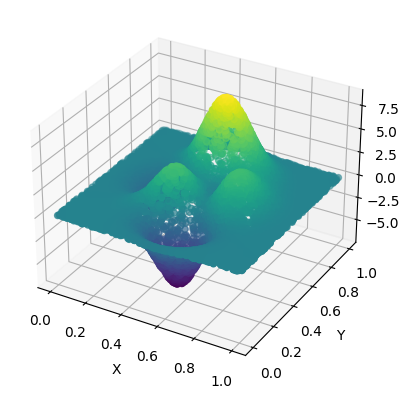

In [265]:
x0_test = np.random.uniform(-3,3,10000)
x1_test = np.random.uniform(-3,3,10000)

Y_test = z(x0_test,x1_test)
Y_test

scaler = MinMaxScaler(feature_range=(0, 1))
vstack_test = np.vstack((x0_test,x1_test)).T
scaled_test = scaler.fit_transform(vstack_test)

x_test = torch.from_numpy(scaled_test)
x0_test = x_test[:, 0]
x1_test = x_test[:, 1]
y_test = torch.from_numpy(Y_test)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Gráfico de dispersión 3D
ax.scatter(x0_test.numpy(), x1_test.numpy(), y_test.numpy(), c=y_test.numpy(), cmap='viridis', marker='o')

# Agregar etiquetas y título
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

# Mostrar el gráfico
plt.show()

In [266]:
pred = model(x_test)
np_pred = pred.detach().numpy()

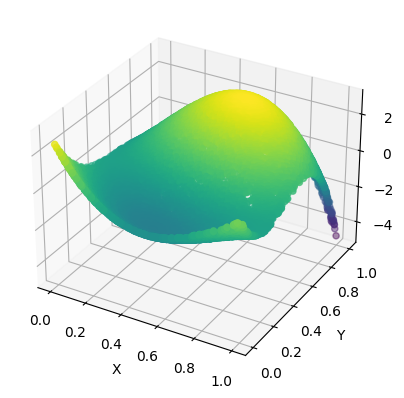

In [267]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Gráfico de dispersión 3D
ax.scatter(x0_test.numpy(), x1_test.numpy(), np_pred, c=np_pred, cmap='viridis', marker='o')

# Agregar etiquetas y título
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

# Mostrar el gráfico
plt.show()

#####Testing 3

In [ ]:
model = Type3ANFIS(x.shape[1], x.dtype, init_rules=3)

prem = torch.tensor([[[0.0462, 0.3922],
                      [0.0971, 0.6555],
                      [0.8235, 0.1712]],

                     [[0.7655, 0.6948],
                      [0.7952, 0.3171],
                      [0.1869, 0.9502]],

                     [[0., 0.],
                      [0., 0.],
                      [0., 0.]],

                     [[0., 0.],
                      [0., 0.],
                      [0., 0.]],

                     [[0., 0.],
                      [0., 0.],
                      [0., 0.]]])

model.set_premises(Parameter(prem, requires_grad=True))

cons = torch.tensor([[-0.3726, -0.1463, 0.6341],
                     [-0.1292, 0.1112, 0.6404],
                     [0.6947, -0.6779, -0.4394],
                     [0., 0., 0.],
                     [-0., 0., -0.]])
model.set_consequents(Parameter(cons, requires_grad=True))

###POO SONFIS

In [ ]:
class SONFIS():
    def __init__(self, max, y, OLSepochs, Ngrow, dGrow, Nsplit, eSplit, Nvanish, lVanish, loss_function=nn.functional.mse_loss, validation=0):
        # Hyperparameters
        self.max = max
        self.y = y
        self.OLSepochs = OLSepochs
        self.Ngrow = Ngrow
        self.dGrow = dGrow
        self.Nsplit = Nsplit
        self.eSplit = eSplit
        self.Nvanish = Nvanish
        self.lVanish = lVanish

        #OLS
        self.ols = OLS(OLSepochs, y, loss_function, validation)

        #Other attributes
        self.freezed = torch.tensor([], dtype=torch.int)
        self.ages = torch.tensor([], dtype=torch.int)
        self.last_best_rules = torch.tensor([-1], dtype=torch.int)

        #history
        self.train_history = torch.tensor([])
        self.val_history = torch.tensor([])


    def __call__(self, ANFISmodel, loader):
        self.ages = torch.zeros(ANFISmodel.rules)
        self.freezed = torch.zeros(ANFISmodel.rules)

        model_updated = True
        i = 0

        self.callOLS(ANFISmodel, loader)
        while(model_updated & (i < self.max)):
            print("\n *******ITERATION:", i+1, " ******* ")
            self.freezed = torch.ones(ANFISmodel.rules)

            #GrowNet
            did_Grow = self.GrowNet(ANFISmodel, loader)

            #Split Sub-network
            if not did_Grow:
                did_Split = self.SplitSubNetwork(ANFISmodel, loader)
            else:
                did_Split = False

            #VanishNet
            did_Vanish = self.VanishNet(ANFISmodel, loader)

            print("\nRules amount:", ANFISmodel.rules, "\n\n")

            model_updated = did_Grow | did_Split | did_Vanish
            if model_updated:
                self.callOLS(ANFISmodel, loader)

            i += 1

        self.freezed = torch.zeros(ANFISmodel.rules)
        self.callOLS(ANFISmodel, loader)


    def callOLS(self, ANFISmodel, loader):
        self.ols(ANFISmodel, loader, self.freezed)
        self.train_history = torch.cat([self.train_history, self.ols.train_history])


    def GrowNet(self, ANFISmodel, loader):
        first_batch = True
        for x_batch, _ in loader:
            #Max firing levels are obtenined
            firing_levels, _, _ = ANFISmodel.intermediate_values(x_batch)
            max_fl = torch.max(firing_levels, dim=1)

            #Boolean mask to filter the samples
            dGrow_mask = (max_fl.values <= self.dGrow**ANFISmodel.input_size)

            #Necesary tensors are defined on the first iteration
            if first_batch:
                bad_samples = torch.tensor([])
                best_bs_rules = torch.tensor([], dtype=torch.int)
                first_batch = False

            #The samples are extracted by concatenating tensors (which are filtered by the mask)
            bad_samples = torch.cat((bad_samples, x_batch[dGrow_mask]), dim=0)
            best_bs_rules = torch.cat((best_bs_rules, max_fl.indices[dGrow_mask]), dim=0)

        #Ngrow parameter filter
        unique_rules, counts = torch.unique(best_bs_rules, return_counts=True)
        Ngrow_mask = (counts > self.Ngrow)

        indices_to_keep = torch.isin(best_bs_rules, unique_rules[Ngrow_mask]).nonzero().squeeze()

        bad_samples = bad_samples[indices_to_keep]
        best_bs_rules = best_bs_rules[indices_to_keep]

        #return False if ANFISmodel is not modified
        if bad_samples.size(0) == 0:
            return False

        #a list of masks called "rules" is created to calculate the necessary means and stds
        rules = [best_bs_rules == value for value in torch.unique(best_bs_rules)]

        #means and stds by rule are calculated
        means = torch.stack([(bad_samples[rule].mean(dim=0)) for rule in rules])
        stds = torch.stack([(bad_samples[rule].std(dim=0)) for rule in rules])

        #Premises and consequents modifications to add a new rule
        new_premises = torch.stack([means.t(), stds.t()], dim=2)
        ANFISmodel.set_premises(torch.cat([ANFISmodel.premises, new_premises], dim=1))

        new_consequents = 2 * torch.rand(new_premises.size(1), ANFISmodel.input_size + 1) - 1
        ANFISmodel.set_consequents(torch.cat([ANFISmodel.consequents, new_consequents]))

        #ages and freezed rules tensors updated
        self.freezed = torch.cat([self.freezed, torch.zeros(new_premises.shape[1])])
        self.ages = torch.cat([self.ages, torch.zeros(new_premises.shape[1], dtype=torch.bool)])

        #return True if ANFISmodel is modified
        return True


    def SplitSubNetwork(self, ANFISmodel, loader):
        first_batch = True
        for x_batch, y_batch in loader:
            #Max firing levels are obtenined
            firing_levels, _, _ = ANFISmodel.intermediate_values(x_batch)
            max_fl = torch.max(firing_levels, dim=1)

            #Necesary tensors are defined on the first iteration
            if first_batch:
                samples = torch.tensor([])
                samples_output = torch.tensor([])
                best_rules = torch.tensor([], dtype=torch.int)
                first_batch = False

            #The best rules are extracted by concatenating tensors
            samples = torch.cat((samples, x_batch), dim=0)
            samples_output = torch.cat((samples_output, y_batch), dim=0)
            best_rules = torch.cat((best_rules, max_fl.indices), dim=0)

        #Nsplit parameter filter
        unique_rules, counts = torch.unique(best_rules, return_counts=True)
        Nsplit_mask = (counts > self.Nsplit)

        indices_to_keep = torch.isin(best_rules, unique_rules[Nsplit_mask]).nonzero().squeeze()

        samples = samples[indices_to_keep]
        samples_output = samples_output[indices_to_keep]
        best_rules = best_rules[indices_to_keep]

        #the rules from best_rules tensor are extracted
        unique_rules = torch.unique(best_rules)

        #MSE is calculated by rule
        mse_values = torch.stack([torch.pow((samples_output[best_rules == rule] - ANFISmodel(samples[best_rules == rule])), 2).mean(dim=0) for rule in unique_rules])

        #eSplit parameter filter
        eSplit_mask = (mse_values > self.eSplit)

        #return Flase if ANFISmodel is not modified
        if ((samples.shape[0] == 0) | (unique_rules[eSplit_mask].shape[0] == 0)):
            return False

        #loop to split each rule one by one and generate the new ones
        new_premises = ANFISmodel.premises #new_premises starts being a copy of the current premises
        new_consequents = ANFISmodel.consequents #same thing with consequents
        for rule in list(torch.flip(unique_rules[eSplit_mask], [0]).long()): #the iteration is performed on a list with the rules in descending order
            #the selected premise is extracted from the new_premises tensor and placed into the to_split tensor
            new_premises = torch.cat([new_premises[:, :rule, :], new_premises[:, rule+1:, :]], dim=1)
            to_split = ANFISmodel.premises[:, rule:rule+1, :].clone()

            #the new ones are generated
            split1 = torch.cat([(to_split[:,:,0] - to_split[:,:,1]/2).unsqueeze(1), (to_split[:,:,1]/2).unsqueeze(1)], dim=2)
            split2 = torch.cat([(to_split[:,:,0] + to_split[:,:,1]/2).unsqueeze(1), (to_split[:,:,1]/2).unsqueeze(1)], dim=2)

            #both are inserted on the new premises tensor
            new_premises = torch.cat([new_premises, torch.cat([split1, split2], dim=1)], dim=1)

            #the corresponding consequent is taken away
            new_consequents = torch.cat([new_consequents[:rule, :], new_consequents[rule+1:, :]], dim=0)

            #two new consequents are added
            new_consequents = torch.cat([new_consequents, 2 * torch.rand(2, ANFISmodel.input_size + 1) - 1], dim=0)

            #same with ages and freezed rules tensor
            self.ages = torch.cat([self.ages[:rule], self.ages[rule+1:]]) #the corresponding rule is taken away
            self.freezed = torch.cat([self.freezed[:rule], self.freezed[rule+1:]])
            self.ages = torch.cat([self.ages, torch.zeros(2, dtype=torch.bool)]) #the new ones are added
            self.freezed = torch.cat([self.freezed, torch.zeros(2)])

        #after the loop, the new parameters are set
        ANFISmodel.set_premises(new_premises)
        ANFISmodel.set_consequents(new_consequents)

        #return True if ANFISmodel is modified
        return True


    def VanishNet(self, ANFISmodel, loader):
        first_batch = True
        for x_batch, _ in loader:
            #Max firing levels are obtenined
            firing_levels, _, _ = ANFISmodel.intermediate_values(x_batch)
            max_fl = torch.max(firing_levels, dim=1)

            #Necesary tensors are defined on the first iteration
            if first_batch:
                best_rules = torch.tensor([], dtype=torch.int)
                first_batch = False

            #the best_rules by sample are extracted
            best_rules = torch.cat((best_rules, max_fl.indices), dim=0)

        #Important info for next operations
        unique_rules, counts = torch.unique(best_rules, return_counts=True)
        all_rules = torch.arange(ANFISmodel.rules)

        #tensor with te amounts of samples modeled for each rule (including those who dont model any sample)
        total_counts = torch.zeros(ANFISmodel.rules, dtype=torch.int64)
        total_counts[unique_rules] = counts

        #if there is no changes with the modeled samples or there is no last_best_rules (first iteration of VanishNet operator)
        if torch.equal(best_rules, self.last_best_rules) | torch.equal(self.last_best_rules, torch.tensor([-1])):
            #ages update
            self.ages += 1
        else:
            #last best rules are inspected (only the ones that appeared in the current iteration)
            last_unique_rules, last_counts = torch.unique(self.last_best_rules, return_counts=True)
            last_total_counts = torch.zeros(ANFISmodel.rules, dtype=torch.int64)
            last_total_counts[last_unique_rules[last_unique_rules < ANFISmodel.rules]] = last_counts[last_unique_rules < ANFISmodel.rules]

            #rules categorization
            improved_rules = all_rules[last_total_counts < total_counts]
            not_improved_rules = all_rules[last_total_counts >= total_counts]

            #ages update
            self.ages[improved_rules] = 0
            self.ages[not_improved_rules] += 1

        #lVanish and Nvanish filters
        mask = ((self.ages > self.lVanish) & (total_counts < self.Nvanish))
        rules_to_eliminate = all_rules[mask]

        if torch.equal(rules_to_eliminate, torch.tensor([], dtype=torch.int64)):
            return False

        #Parameters update (the rules are eliminated)
        new_premises = ANFISmodel.premises
        new_consequents = ANFISmodel.consequents
        for rule in rules_to_eliminate:
            new_premises = torch.cat([new_premises[:, :rule, :], new_premises[:, rule+1:, :]], dim=1)
            new_consequents = torch.cat([new_consequents[:rule, :], new_consequents[rule+1:, :]], dim=0)
            self.ages = torch.cat([self.ages[:rule], self.ages[rule+1:]]) #the corresponding rule is taken away
            self.freezed = torch.cat([self.freezed[:rule], self.freezed[rule+1:]])

        #New parameters are set
        ANFISmodel.set_premises(new_premises)
        ANFISmodel.set_consequents(new_consequents)

        #update last best rules
        self.last_best_rules = best_rules

        #The best rules tensor is returned for next iterations, also the ages
        return True

In [171]:
class SONFIS():
    def __init__(self, max, y, OLSepochs, Ngrow, dGrow, Nsplit, eSplit, Nvanish, lVanish, loss_function=nn.functional.mse_loss, validation=0):
        # Hyperparameters
        self.max = max
        self.y = y
        self.OLSepochs = OLSepochs
        self.Ngrow = Ngrow
        self.dGrow = dGrow
        self.Nsplit = Nsplit
        self.eSplit = eSplit
        self.Nvanish = Nvanish
        self.lVanish = lVanish

        #OLS
        self.ols = OLS(OLSepochs, y, loss_function, validation)

        #Other attributes
        self.freezed = torch.tensor([], dtype=torch.int)
        self.ages = torch.tensor([], dtype=torch.int)
        self.last_best_rules = torch.tensor([-1], dtype=torch.int)

        #history
        self.train_history = torch.tensor([])
        self.val_history = torch.tensor([])


    def __call__(self, ANFISmodel, loader):
        self.ages = torch.zeros(ANFISmodel.rules)
        self.freezed = torch.zeros(ANFISmodel.rules)

        model_updated = True
        i = 0

        #print("ols")
        self.callOLS(ANFISmodel, loader)
        #print("model.premises", model.premises)
        #print(hola)
        while(model_updated & (i < self.max)):
            print("\n *******ITERATION:", i+1, " ******* ")
            self.freezed = torch.ones(ANFISmodel.rules)

            #GrowNet
            did_Grow = self.GrowNet(ANFISmodel, loader)
            if did_Grow:
                print("grow")
                print("model.consequents", model.consequents)

            #Split Sub-network
            if not did_Grow:
                did_Split = self.SplitSubNetwork(ANFISmodel, loader)
                if did_Split:
                    print("split")
                    print("model.consequents", model.consequents)
            else:
                did_Split = False

            #VanishNet
            did_Vanish = self.VanishNet(ANFISmodel, loader)
            if did_Vanish:
                print("vanish")
                print("model.consequents", model.consequents)

            print("\nRules amount:", ANFISmodel.rules, "\n\n")

            model_updated = did_Grow | did_Split | did_Vanish
            if model_updated:
                print("ols")
                self.callOLS(ANFISmodel, loader)
                print("model.consequents", model.consequents)

            i += 1

        self.freezed = torch.zeros(ANFISmodel.rules)
        #print("ols")
        self.callOLS(ANFISmodel, loader)
        #print("model.premises", model.premises)


    def callOLS(self, ANFISmodel, loader):
        self.ols(ANFISmodel, loader, self.freezed)
        self.train_history = torch.cat([self.train_history, self.ols.train_history])

    def GrowNet(self, ANFISmodel, loader):
        first_batch = True
        for x_batch, y_batch in loader:
            #Max firing levels are obtenined
            firing_levels, _, _ = ANFISmodel.intermediate_values(x_batch)
            max_fl = torch.max(firing_levels, dim=1)

            #Boolean mask to filter the samples
            dGrow_mask = (max_fl.values <= self.dGrow**ANFISmodel.input_size)

            #Necesary tensors are defined on the first iteration
            if first_batch:
                bad_samples = torch.tensor([])
                best_bs_rules = torch.tensor([], dtype=torch.int)
                first_batch = False

            #The samples are extracted by concatenating tensors (which are filtered by the mask)
            bad_samples = torch.cat((bad_samples, x_batch[dGrow_mask]), dim=0)
            best_bs_rules = torch.cat((best_bs_rules, max_fl.indices[dGrow_mask]), dim=0)

        #Ngrow parameter filter
        unique_rules, counts = torch.unique(best_bs_rules, return_counts=True)
        Ngrow_mask = (counts > self.Ngrow)

        indices_to_keep = torch.isin(best_bs_rules, unique_rules[Ngrow_mask]).nonzero().squeeze()

        bad_samples = bad_samples[indices_to_keep]
        best_bs_rules = best_bs_rules[indices_to_keep]

        #return False if ANFISmodel is not modified
        if bad_samples.size(0) == 0:
            return False

        #a list of masks called "rules" is created to calculate the necessary means and stds
        rules = [best_bs_rules == value for value in torch.unique(best_bs_rules)]

        #means and stds by rule are calculated
        means = torch.stack([(bad_samples[rule].mean(dim=0)) for rule in rules])
        stds = torch.stack([(bad_samples[rule].std(dim=0)) for rule in rules])

        #Premises and consequents modifications to add a new rule
        new_premises = torch.stack([means.t(), stds.t()], dim=2)
        ANFISmodel.set_premises(torch.cat([ANFISmodel.premises, new_premises], dim=1))

        new_consequents = 2 * torch.rand(new_premises.size(1), ANFISmodel.input_size + 1) - 1
        ANFISmodel.set_consequents(torch.cat([ANFISmodel.consequents, new_consequents]))

        #ages and freezed rules tensors updated
        self.freezed = torch.cat([self.freezed, torch.zeros(new_premises.shape[1])])
        self.ages = torch.cat([self.ages, torch.zeros(new_premises.shape[1], dtype=torch.bool)])

        #return True if ANFISmodel is modified
        return True


    def SplitSubNetwork(self, ANFISmodel, loader):
        first_batch = True
        for x_batch, y_batch in loader:
            #Max firing levels are obtenined
            firing_levels, _, _ = ANFISmodel.intermediate_values(x_batch)
            max_fl = torch.max(firing_levels, dim=1)

            #Necesary tensors are defined on the first iteration
            if first_batch:
                samples = torch.tensor([])
                samples_output = torch.tensor([])
                best_rules = torch.tensor([], dtype=torch.int)
                first_batch = False

            #The best rules are extracted by concatenating tensors
            samples = torch.cat((samples, x_batch), dim=0)
            samples_output = torch.cat((samples_output, y_batch), dim=0)
            best_rules = torch.cat((best_rules, max_fl.indices), dim=0)

        #Nsplit parameter filter
        unique_rules, counts = torch.unique(best_rules, return_counts=True)
        Nsplit_mask = (counts > self.Nsplit)

        indices_to_keep = torch.isin(best_rules, unique_rules[Nsplit_mask]).nonzero().squeeze()

        samples = samples[indices_to_keep]
        samples_output = samples_output[indices_to_keep]
        best_rules = best_rules[indices_to_keep]

        #the rules from best_rules tensor are extracted
        unique_rules = torch.unique(best_rules)

        #MSE is calculated by rule
        mse_values = torch.stack([torch.pow((samples_output[best_rules == rule] - ANFISmodel(samples[best_rules == rule])), 2).mean(dim=0) for rule in unique_rules])

        #eSplit parameter filter
        eSplit_mask = (mse_values > self.eSplit)

        #return Flase if ANFISmodel is not modified
        if ((samples.shape[0] == 0) | (unique_rules[eSplit_mask].shape[0] == 0)):
            return False

        #loop to split each rule one by one and generate the new ones
        new_premises = ANFISmodel.premises #new_premises starts being a copy of the current premises
        new_consequents = ANFISmodel.consequents #same thing with consequents
        for rule in list(torch.flip(unique_rules[eSplit_mask], [0]).long()): #the iteration is performed on a list with the rules in descending order
            #the selected premise is extracted from the new_premises tensor and placed into the to_split tensor
            new_premises = torch.cat([new_premises[:, :rule, :], new_premises[:, rule+1:, :]], dim=1)
            to_split = ANFISmodel.premises[:, rule:rule+1, :].clone()

            #the new ones are generated
            split1 = torch.cat([(to_split[:,:,0] - to_split[:,:,1]/2).unsqueeze(1), (to_split[:,:,1]/2).unsqueeze(1)], dim=2)
            split2 = torch.cat([(to_split[:,:,0] + to_split[:,:,1]/2).unsqueeze(1), (to_split[:,:,1]/2).unsqueeze(1)], dim=2)

            #both are inserted on the new premises tensor
            new_premises = torch.cat([new_premises, torch.cat([split1, split2], dim=1)], dim=1)

            #the corresponding consequent is taken away
            new_consequents = torch.cat([new_consequents[:rule, :], new_consequents[rule+1:, :]], dim=0)

            #two new consequents are added
            new_consequents = torch.cat([new_consequents, 2 * torch.rand(2, ANFISmodel.input_size + 1) - 1], dim=0)

            #same with ages tensor
            self.ages = torch.cat([self.ages[:rule], self.ages[rule+1:]]) #the corresponding rule is taken away
            self.freezed = torch.cat([self.freezed[:rule], self.freezed[rule+1:]])
            self.ages = torch.cat([self.ages, torch.zeros(2, dtype=torch.bool)]) #the new ones are added
            self.freezed = torch.cat([self.freezed, torch.zeros(2)])

        #after the loop, the new parameters are set
        ANFISmodel.set_premises(new_premises)
        ANFISmodel.set_consequents(new_consequents)

        #return True if ANFISmodel is modified
        return True


    def VanishNet(self, ANFISmodel, loader):
        first_batch = True
        for x_batch, y_batch in loader:
            #Max firing levels are obtenined
            firing_levels, _, _ = ANFISmodel.intermediate_values(x_batch)
            max_fl = torch.max(firing_levels, dim=1)

            #Necesary tensors are defined on the first iteration
            if first_batch:
                best_rules = torch.tensor([], dtype=torch.int)
                first_batch = False

            #the best_rules by sample are extracted
            best_rules = torch.cat((best_rules, max_fl.indices), dim=0)

        #Important info for next operations
        unique_rules, counts = torch.unique(best_rules, return_counts=True)
        all_rules = torch.arange(ANFISmodel.rules)

        #tensor with te amounts of samples modeled for each rule (including those who dont model any sample)
        total_counts = torch.zeros(ANFISmodel.rules, dtype=torch.int64)
        total_counts[unique_rules] = counts

        #if there is no changes with the modeled samples or there is no last_best_rules (first iteration of VanishNet operator)
        if torch.equal(best_rules, self.last_best_rules) | torch.equal(self.last_best_rules, torch.tensor([-1])):
            #ages update
            self.ages += 1
        else:
            #last best rules are inspected (only the ones that appeared in the current iteration)
            last_unique_rules, last_counts = torch.unique(self.last_best_rules, return_counts=True)
            last_total_counts = torch.zeros(ANFISmodel.rules, dtype=torch.int64)
            last_total_counts[last_unique_rules[last_unique_rules < ANFISmodel.rules]] = last_counts[last_unique_rules < ANFISmodel.rules]

            #rules categorization
            improved_rules = all_rules[last_total_counts < total_counts]
            not_improved_rules = all_rules[last_total_counts >= total_counts]

            #ages update
            self.ages[improved_rules] = 0
            self.ages[not_improved_rules] += 1

        #lVanish and Nvanish filters
        mask = ((self.ages > self.lVanish) & (total_counts < self.Nvanish))
        rules_to_eliminate = all_rules[mask]

        if torch.equal(rules_to_eliminate, torch.tensor([], dtype=torch.int64)):
            return False

        #Parameters update (the rules are eliminated)
        new_premises = ANFISmodel.premises
        new_consequents = ANFISmodel.consequents
        for rule in rules_to_eliminate:
            new_premises = torch.cat([new_premises[:, :rule, :], new_premises[:, rule+1:, :]], dim=1)
            new_consequents = torch.cat([new_consequents[:rule, :], new_consequents[rule+1:, :]], dim=0)
            self.ages = torch.cat([self.ages[:rule], self.ages[rule+1:]]) #the corresponding rule is taken away
            self.freezed = torch.cat([self.freezed[:rule], self.freezed[rule+1:]])

        #New parameters are set
        ANFISmodel.set_premises(new_premises)
        ANFISmodel.set_consequents(new_consequents)

        #update last best rules
        self.last_best_rules = best_rules

        #The best rules tensor is returned for next iterations, also the ages
        return True

####Testing

In [172]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from mpl_toolkits.mplot3d import Axes3D


def z(x, y):
  return ((3) * ((1-x)**2) * (np.exp(-(x**2)-((y+1)**2))) - (10) * ((x/5)-(x**3)-(y**5)) * (np.exp(-(x**2)-(y**2))) - (1/3)*np.exp(-(x+1)**2-(y**2)))


x0 = np.random.uniform(-3,3,10000)
x1 = np.random.uniform(-3,3,10000)

e = np.random.normal(0,0.4,10000)
Y = z(x0,x1) + e


scaler = MinMaxScaler(feature_range=(0, 1))
vstack_train = np.vstack((x0,x1)).T
scaled_train = scaler.fit_transform(vstack_train)


loader = data.DataLoader(data.TensorDataset(torch.from_numpy(scaled_train), torch.from_numpy(Y)), batch_size = 8, shuffle = True)
x_trainset = loader.dataset.tensors[0]

In [173]:
model = Type3ANFIS(x_trainset.shape[1], x_trainset.dtype, x_train=x_trainset)

In [174]:
print(f"ANFIStest_model premises: {model.premises}")
print(f"ANFIStest_model consequents: {model.consequents}")

ANFIStest_model premises: tensor([[[0.4957, 0.2876]],

        [[0.5042, 0.2906]]], dtype=torch.float64)
ANFIStest_model consequents: tensor([[-0.2649,  0.8262,  0.5544]], dtype=torch.float64)


In [175]:
max = 10
y = 0.01
OLSepochs = 10
Ngrow = 1000
dGrow = 1.7
Nsplit = 1200
eSplit = 1.1
Nvanish = 800
lVanish = 2

In [176]:
sonfis = SONFIS(max, y, OLSepochs, Ngrow, dGrow, Nsplit, eSplit, Nvanish, lVanish)

In [177]:
print(f"ANFIStest_model premises: {model.premises}")
print(f"ANFIStest_model consequents: {model.consequents}")

ANFIStest_model premises: tensor([[[0.4957, 0.2876]],

        [[0.5042, 0.2906]]], dtype=torch.float64)
ANFIStest_model consequents: tensor([[-0.2649,  0.8262,  0.5544]], dtype=torch.float64)


#####GrowNet

In [ ]:
sonfis.GrowNet(model, loader)

True

In [ ]:
print(f"ANFIStest_model premises: {model.premises}")
print(f"ANFIStest_model consequents: {model.consequents}")

ANFIStest_model premises: tensor([[[0.4984, 0.2891],
         [0.4984, 0.2891],
         [0.4984, 0.2903]],

        [[0.4961, 0.2903],
         [0.4961, 0.2903],
         [0.4960, 0.2915]]], dtype=torch.float64)
ANFIStest_model consequents: tensor([[-0.1596, -0.2571,  0.8589],
        [ 0.1675, -0.1732,  0.3572],
        [-0.2782, -0.7910, -0.5262]], dtype=torch.float64)


#####Split Sub-network

In [ ]:
sonfis.SplitSubNetwork(model, loader)

True

In [ ]:
print(f"ANFIStest_model premises: {model.premises}")
print(f"ANFIStest_model consequents: {model.consequents}")

ANFIStest_model premises: tensor([[[0.3532, 0.1451],
         [0.6435, 0.1451],
         [0.3538, 0.1446],
         [0.6429, 0.1446],
         [0.3538, 0.1446],
         [0.6429, 0.1446]],

        [[0.3503, 0.1458],
         [0.6418, 0.1458],
         [0.3509, 0.1452],
         [0.6412, 0.1452],
         [0.3509, 0.1452],
         [0.6412, 0.1452]]], dtype=torch.float64)
ANFIStest_model consequents: tensor([[-0.1767, -0.5364, -0.9230],
        [ 0.7614, -0.4277, -0.4868],
        [ 0.4805,  0.1217,  0.6861],
        [ 0.3098, -0.6186, -0.0304],
        [-0.0681, -0.1632, -0.8740],
        [ 0.4960, -0.5918,  0.7483]], dtype=torch.float64)


#####VanishNet

In [ ]:
sonfis.ages = torch.tensor([0, 0, 0, 0, 0, 0])
print(f"ages: {sonfis.ages}")

ages: tensor([0, 0, 0, 0, 0, 0])


In [ ]:
sonfis.VanishNet(model, loader)

True

In [ ]:
print(f"ages: {sonfis.ages}")
print(f"ANFIStest_model premises: {model.premises}")
print(f"ANFIStest_model consequents: {model.consequents}")

ages: tensor([5, 5])
ANFIStest_model premises: tensor([[[0.3532, 0.1451],
         [0.6435, 0.1451]],

        [[0.3503, 0.1458],
         [0.6418, 0.1458]]], dtype=torch.float64)
ANFIStest_model consequents: tensor([[-0.1767, -0.5364, -0.9230],
        [ 0.7614, -0.4277, -0.4868]], dtype=torch.float64)


#####SONFIS

In [178]:
model = Type3ANFIS(x_trainset.shape[1], x_trainset.dtype, x_train=x_trainset)

In [179]:
max = 10
y = 0.01
OLSepochs = 10
Ngrow = 1600
dGrow = 1.7
Nsplit = 1200
eSplit = 1.1
Nvanish = 800
lVanish = 2

In [180]:
sonfis = SONFIS(max, y, OLSepochs, Ngrow, dGrow, Nsplit, eSplit, Nvanish, lVanish)

In [181]:
print(f"ANFIStest_model premises: {model.premises}")
print(f"ANFIStest_model consequents: {model.consequents}")

ANFIStest_model premises: tensor([[[0.4957, 0.2876]],

        [[0.5042, 0.2906]]], dtype=torch.float64)
ANFIStest_model consequents: tensor([[ 0.3338, -0.0701, -0.3479]], dtype=torch.float64)


In [182]:
sonfis(model, loader)


 *******ITERATION: 1  ******* 
grow
model.consequents tensor([[ 0.6905,  2.4902, -1.2258],
        [-0.0258,  0.6906,  0.8122]], dtype=torch.float64)

Rules amount: 2 


ols
model.consequents tensor([[ 3.9007, 13.0387, -7.1760],
        [-2.4379, -8.4395,  4.4346]], dtype=torch.float64)

 *******ITERATION: 2  ******* 
grow
model.consequents tensor([[ 3.9007, 13.0387, -7.1760],
        [-2.4379, -8.4395,  4.4346],
        [ 0.5313,  0.5659, -0.5009],
        [-0.4695,  0.7694, -0.1969]], dtype=torch.float64)

Rules amount: 4 


ols
model.consequents tensor([[ 3.9007e+00,  1.3039e+01, -7.1760e+00],
        [-2.4379e+00, -8.4395e+00,  4.4346e+00],
        [ 1.7260e-91, -8.0508e-91,  7.5985e-90],
        [-3.9484e-09, -2.0010e-08,  4.1579e-08]], dtype=torch.float64)

 *******ITERATION: 3  ******* 
grow
model.consequents tensor([[ 3.9007e+00,  1.3039e+01, -7.1760e+00],
        [-2.4379e+00, -8.4395e+00,  4.4346e+00],
        [ 1.7260e-91, -8.0508e-91,  7.5985e-90],
        [-3.9484e-09, -2

In [183]:
sonfis.ages

tensor([0., 1., 0.])

In [184]:
print(f"ANFIStest_model premises: {model.premises}")
print(f"ANFIStest_model consequents: {model.consequents}")

ANFIStest_model premises: tensor([[[ 7.0614e+00,  3.7432e+02],
         [-1.8227e+03, -7.0674e+01],
         [-1.7901e+02,  8.3387e+00]],

        [[ 1.4132e+01,  3.6411e+02],
         [ 1.1001e+04,  5.8489e+02],
         [-5.1062e+02, -6.8981e+01]]], dtype=torch.float64)
ANFIStest_model consequents: tensor([[  6.9050e-01,   2.4902e+00,  -1.2258e+00],
        [ 2.6103e-222,  1.1047e-221, -7.6881e-222],
        [-1.6182e-113,  3.1124e-113, -1.6940e-112]], dtype=torch.float64)


In [185]:
sonfis.train_history

tensor([3.3548, 3.3548, 3.3548, 3.3548, 3.3548, 3.3548, 3.3548, 3.3548, 3.3548,
        3.3548, 3.3548, 3.3548, 3.3548, 3.3548, 3.3548, 3.3548, 3.3548, 3.3548,
        3.3548, 3.3548, 2.4254, 2.4207, 2.4162, 2.4118, 2.4079, 2.4049, 2.4026,
        2.4007, 2.3991, 2.3977, 3.3548, 3.3548, 3.3548, 3.3548, 3.3548, 3.3548,
        3.3548, 3.3548, 3.3548, 3.3548, 2.4254, 2.4207, 2.4162, 2.4118, 2.4079,
        2.4049, 2.4026, 2.4007, 2.3991, 2.3977, 3.0013, 3.2462, 2.2529, 2.5176,
        3.2298, 3.7120, 3.0014, 3.7001, 3.1502, 2.3977, 3.3548, 3.3548, 3.3548,
        3.3548, 3.3548, 3.3548, 3.3548, 3.3548, 3.3548, 3.3548, 2.4254, 2.4207,
        2.4162, 2.4118, 2.4079, 2.4049, 2.4026, 2.4007, 2.3991, 2.3977, 3.0013,
        3.2462, 2.2529, 2.5176, 3.2298, 3.7120, 3.0014, 3.7001, 3.1502, 2.3977,
        2.4063, 2.3938, 2.3220, 2.3625, 2.3648, 2.3370, 2.3631, 2.3371, 2.3638,
        2.3694, 3.3548, 3.3548, 3.3548, 3.3548, 3.3548, 3.3548, 3.3548, 3.3548,
        3.3548, 3.3548, 2.4254, 2.4207, 

####MATLAB testing

In [ ]:
import pandas as pd

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
data_path = "/content/drive/MyDrive/Práctica Industrial/Experimentación inicial/Matlab_Example/Agua150321.xlsx"

In [ ]:
data_frame = pd.read_excel(data_path, sheet_name='pred')

In [ ]:
columns = [f'x{i}' for i in range(data_frame.shape[1] - 1)] + ['y']
data_frame.columns = columns

In [ ]:
data_frame

,x0,x1,x2,x3,x4,y
0,18.5,19.0,20.1,20.6,0.0,18.0
1,18.0,18.5,19.0,20.1,0.0,18.0
2,18.0,18.0,18.5,19.0,0.0,18.0
3,18.0,18.0,18.0,18.5,0.0,17.6
4,17.6,18.0,18.0,18.0,0.0,17.6
...,...,...,...,...,...,...
6439,26.2,26.9,27.0,26.0,0.0,24.5
6440,24.5,26.2,26.9,27.0,0.0,23.9
6441,23.9,24.5,26.2,26.9,0.0,23.2
6442,23.2,23.9,24.5,26.2,0.0,23.5


In [ ]:
X = torch.tensor(data_frame.iloc[:, :-1].values)
Y = torch.tensor(data_frame.iloc[:, -1].values)

In [ ]:
x_train = X[:6205, :]
x_test = X[6205:, :]
y_train = Y[:6205]
y_test = Y[6205:]

In [ ]:
train_loader = data.DataLoader(data.TensorDataset(x_train, y_train), batch_size = 8)
test_loader = data.DataLoader(data.TensorDataset(x_test, y_test), batch_size = 8)

In [ ]:
#Redundant
x_train = train_loader.dataset.tensors[0]

In [ ]:
model = Type3ANFIS(x_train.shape[1], init_rules=1, x_train=x_train)

In [ ]:
model.premises

tensor([[[42.2808, 37.2807]],

        [[42.2742, 37.2811]],

        [[42.2676, 37.2812]],

        [[42.2605, 37.2810]],

        [[ 3.4120, 11.9539]]], dtype=torch.float64)

In [ ]:
model.consequents

tensor([[ 0.9115, -0.1962,  0.8960,  0.7776, -0.6001,  0.9179]],
       dtype=torch.float64)